# Validación externa supervisada – Conv1D TSTR con SWaT A12 etiquetado

Este notebook evalúa externamente los tres detectores Conv1D entrenados en la validación interna:

1. `real_only`
2. `synthetic_only`
3. `real_plus_synthetic`

La evaluación externa usa el dataset **SWaT A12 OTDataset Mar 26**, previamente etiquetado a partir del cronograma de ataques.

## Propósito

El objetivo es comparar si el entrenamiento con datos sintéticos mejora la detección de ataques reales bajo un escenario externo y etiquetado.

A diferencia de la validación interna, aquí sí se calculan métricas supervisadas porque ya existe una etiqueta binaria:

- `0`: ventana normal
- `1`: ventana bajo ataque

## Flujo general

1. Cargar modelos entrenados por escenario.
2. Cargar scalers y configuración usados durante la validación interna.
3. Cargar el CSV A12 etiquetado.
4. Aplicar el mismo preprocesamiento del detector.
5. Construir ventanas con `window_size` y `stride` del entrenamiento.
6. Etiquetar cada ventana a partir de `attack_label`.
7. Calcular errores de reconstrucción.
8. Aplicar umbrales (`tau`) por percentil.
9. Comparar precision, recall, F1, ROC-AUC y PR-AUC.


## 1. Imports y configuración inicial

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)


In [2]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 2. Rutas del proyecto

In [3]:
current_dir = Path.cwd()

if (current_dir / "data").exists():
    PROJECT_ROOT = current_dir
else:
    PROJECT_ROOT = current_dir.parent

A12_LABELED_PATH = PROJECT_ROOT / "data" / "clean" / "SWaT.A12_OTDataset_Mar_26" / "11-Mar-2026_0900_1700_labeled.csv"

INTERNAL_ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "tstr_internal_validation"
MODELS_DIR = PROJECT_ROOT / "models" / "detectors" / "conv1d_tstr_internal"

EXTERNAL_RESULTS_DIR = PROJECT_ROOT / "artifacts" / "tstr_external_validation"
EXTERNAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("A12_LABELED_PATH:", A12_LABELED_PATH)
print("INTERNAL_ARTIFACTS_DIR:", INTERNAL_ARTIFACTS_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("EXTERNAL_RESULTS_DIR:", EXTERNAL_RESULTS_DIR)


PROJECT_ROOT: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation
A12_LABELED_PATH: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\clean\SWaT.A12_OTDataset_Mar_26\11-Mar-2026_0900_1700_labeled.csv
INTERNAL_ARTIFACTS_DIR: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\artifacts\tstr_internal_validation
MODELS_DIR: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_tstr_internal
EXTERNAL_RESULTS_DIR: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\artifacts\tstr_external_validation


In [4]:
required_paths = [
    A12_LABELED_PATH,
    INTERNAL_ARTIFACTS_DIR / "scaler_cont.pkl",
    INTERNAL_ARTIFACTS_DIR / "disc_max.pkl",
    INTERNAL_ARTIFACTS_DIR / "columns_config.json",
    INTERNAL_ARTIFACTS_DIR / "config.json",
    MODELS_DIR,
]

missing_paths = [str(p) for p in required_paths if not p.exists()]

if missing_paths:
    raise FileNotFoundError(
        "Faltan archivos requeridos. Verifica que corriste el notebook de validación interna "
        "con la celda de guardado completa y el notebook de preparación A12.\n"
        + "\n".join(missing_paths)
    )

print("All required paths found.")


All required paths found.


## 3. Cargar configuración de validación interna

Se cargan:

- columnas continuas y discretas usadas por el detector;
- scaler de continuas (`StandardScaler`);
- máximos de discretas (`disc_max`);
- configuración general del entrenamiento interno;
- modelos por escenario.


In [5]:
with open(INTERNAL_ARTIFACTS_DIR / "columns_config.json", "r") as f:
    columns_config = json.load(f)

with open(INTERNAL_ARTIFACTS_DIR / "config.json", "r") as f:
    internal_config = json.load(f)

scaler_cont = joblib.load(INTERNAL_ARTIFACTS_DIR / "scaler_cont.pkl")
disc_max = joblib.load(INTERNAL_ARTIFACTS_DIR / "disc_max.pkl")

continuous_cols = columns_config["continuous_cols"]
discrete_cols = columns_config["discrete_cols"]
feature_cols = columns_config["feature_cols"]

WINDOW_SIZE = int(internal_config["window_size"])
STRIDE = int(internal_config["stride"])

SCENARIOS = internal_config["scenarios"]

print("Scenarios:", SCENARIOS)
print("Window size:", WINDOW_SIZE)
print("Stride:", STRIDE)
print("Continuous cols:", len(continuous_cols))
print("Discrete cols:", len(discrete_cols))
print("Total feature cols:", len(feature_cols))


Scenarios: ['real_only', 'synthetic_only', 'real_plus_synthetic']
Window size: 60
Stride: 5
Continuous cols: 23
Discrete cols: 26
Total feature cols: 49


## 4. Cargar y revisar dataset A12 etiquetado

In [6]:
a12_df = pd.read_csv(A12_LABELED_PATH)

print("A12 labeled shape:", a12_df.shape)
display(a12_df.head())
display(a12_df[["attack_label", "attack_id", "attack_name"]].head())


A12 labeled shape: (28860, 93)


C:\Users\Juan\AppData\Local\Temp\ipykernel_2080\4140888234.py:1: DtypeWarning: Columns (0: P2_STATE, 1: FIT201.Pv, 2: AIT201.Pv, 3: AIT202.Pv, 4: AIT203.Pv, 5: MV201.Status, 6: P201.Status, 7: P202.Status, 8: P203.Status, 9: P204.Status, 10: P205.Status, 11: P206.Status, 12: P207.Status, 13: P208.Status, 14: attack_name, 15: attack_targets, 16: attack_start_time, 17: attack_end_time) have mixed types. Specify dtype option on import or set low_memory=False.
  a12_df = pd.read_csv(A12_LABELED_PATH)


,t_stamp,P1_STATE,LIT101.Pv,FIT101.Pv,MV101.Status,P101.Status,P102.Status,P2_STATE,FIT201.Pv,AIT201.Pv,AIT202.Pv,AIT203.Pv,MV201.Status,P201.Status,P202.Status,P203.Status,P204.Status,P205.Status,P206.Status,P207.Status,P208.Status,LS201.Alarm,LS202.Alarm,LSL203.Alarm,LSLL203.Alarm,P3_STATE,AIT301.Pv,AIT302.Pv,AIT303.Pv,LIT301.Pv,FIT301.Pv,DPIT301.Pv,MV301.Status,MV302.Status,MV303.Status,MV304.Status,P301.Status,P302.Status,PSH301.Alarm,DPSH301.Alarm,P4_STATE,LIT401.Pv,FIT401.Pv,AIT401.Pv,AIT402.Pv,P401.Status,P402.Status,P403.Status,P404.Status,UV401.Status,LS401.Alarm,P5_STATE,FIT501.Pv,FIT502.Pv,FIT503.Pv,FIT504.Pv,AIT501.Pv,AIT502.Pv,AIT503.Pv,AIT504.Pv,PIT501.Pv,PIT502.Pv,PIT503.Pv,P501.Status,P501.Speed,P502.Status,P502.Speed,MV501.Status,MV502.Status,MV503.Status,MV504.Status,PSH501.Alarm,PSL501.Alarm,P6_STATE,LIT601.Pv,LIT602.Pv,FIT601.Pv,FIT602.Pv,P601.Status,P602.Status,P603.Status,LSH601.Alarm,LSL601.Alarm,LSH602.Alarm,LSL602.Alarm,LSH603.Alarm,LSL603.Alarm,attack_label,attack_id,attack_name,attack_targets,attack_start_time,attack_end_time
0,2026-03-11 09:00:00,1,809.6666,0.0,1,1,1,1,0.0,99.36555,9.99827,152.525,1,1,1,1,1,1,1,1,1,Inactive,Inactive,Inactive,Active,1,7.714322,194.711563,31.01991,655.480957,0.0,3.617389,1,1,1,1,1,1,Bad Input,Bad Input,1,1006.39581,0.0,0.0,203.896439,1,1,1,1,1,Inactive,1,0.002692,0.001793,0.001408,0.0,8.918098,305.152527,163.195328,29.838503,9.068188,0.0,6.777109,1,0.0,1,0.0,1,1,1,1,Bad Input,Bad Input,1,341.643158,548.769531,0.0,0.884247,1,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active,0,NaN,NaN,NaN,NaN,NaN
1,2026-03-11 09:00:01,1,809.6666,0.0,1,1,1,1,0.0,99.36555,9.994104,152.525,1,1,1,1,1,1,1,1,1,Inactive,Inactive,Inactive,Active,1,7.714322,194.711563,31.01991,655.480957,0.0,3.617389,1,1,1,1,1,1,Bad Input,Bad Input,1,1006.43427,0.0,0.0,203.896439,1,1,1,1,1,Inactive,1,0.002692,0.001793,0.001408,0.0,8.919380,305.152527,163.195328,29.838503,9.068188,0.0,6.777109,1,0.0,1,0.0,1,1,1,1,Bad Input,Bad Input,1,341.643158,548.769531,0.0,0.897863,1,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active,0,NaN,NaN,NaN,NaN,NaN
2,2026-03-11 09:00:02,1,809.6666,0.0,1,1,1,1,0.0,99.36555,9.988977,152.525,1,1,1,1,1,1,1,1,1,Inactive,Inactive,Inactive,Active,1,7.714322,194.711563,31.01991,655.480957,0.0,3.617389,1,1,1,1,1,1,Bad Input,Bad Input,1,1006.20355,0.0,0.0,203.896439,1,1,1,1,1,Inactive,1,0.002692,0.001793,0.001408,0.0,8.921623,305.152527,163.195328,29.838503,9.068188,0.0,6.777109,1,0.0,1,0.0,1,1,1,1,Bad Input,Bad Input,1,341.739300,548.769531,0.0,0.897863,1,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active,0,NaN,NaN,NaN,NaN,NaN
3,2026-03-11 09:00:03,1,809.6666,0.0,1,1,1,1,0.0,99.36555,9.98609352,152.525,1,1,1,1,1,1,1,1,1,Inactive,Inactive,Inactive,Active,1,7.714322,194.711563,31.01991,655.480957,0.0,3.617389,1,1,1,1,1,1,Bad Input,Bad Input,1,1006.35736,0.0,0.0,203.896439,1,1,1,1,1,Inactive,1,0.002692,0.001793,0.001408,0.0,8.924828,305.152527,163.195328,29.838503,9.068188,0.0,6.777109,1,0.0,1,0.0,1,1,1,1,Bad Input,Bad Input,1,341.867462,548.769531,0.0,0.895140,1,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active,0,NaN,NaN,NaN,NaN,NaN
4,2026-03-11 09:00:04,1,810.2162,0.0,1,1,1,1,0.0,99.36555,9.982569,152.525,1,1,1,1,1,1,1,1,1,Inactive,Inactive,Inactive,Active,1,7.714322,194.711563,31.01991,654.960266,0.0,3.617389,1,1,1,1,1,1,Bad Input,Bad Input,1,1006.62653,0.0,0.0,203.896439,1,1,1,1,1,Inactive,1,0.002692,0.001793,0.001408,0.0,8.927071,305.152527,163.195328,29.838503,9.068188,0.0,6.777109,1,0.0,1,0.0,1,1,1,1,Bad Input,Bad Input,1,341.867462,548.769531,0.0,0.896582,1,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active,0,NaN,NaN,NaN,NaN,NaN


,attack_label,attack_id,attack_name
0,0,NaN,NaN
1,0,NaN,NaN
2,0,NaN,NaN
3,0,NaN,NaN
4,0,NaN,NaN


In [7]:
# Parsear timestamp
a12_df["t_stamp"] = pd.to_datetime(a12_df["t_stamp"], errors="coerce")

if a12_df["t_stamp"].isna().any():
    raise ValueError("Hay timestamps inválidos en A12 etiquetado.")

a12_df = a12_df.sort_values("t_stamp").reset_index(drop=True)

print("Start:", a12_df["t_stamp"].min())
print("End:", a12_df["t_stamp"].max())
print("Rows:", len(a12_df))

display(a12_df["attack_label"].value_counts().rename_axis("attack_label").reset_index(name="rows"))


Start: 2026-03-11 09:00:00
End: 2026-03-11 17:00:59
Rows: 28860


,attack_label,rows
0,0,25740
1,1,3120


In [8]:
required_a12_cols = ["t_stamp", "attack_label"] + continuous_cols + discrete_cols

missing_cols = [c for c in required_a12_cols if c not in a12_df.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
    raise ValueError(
        "El dataset externo no contiene todas las columnas requeridas por el detector. "
        "Revisa diferencias entre A7 2020 y A12 2026."
    )

print("All required detector columns are present in A12.")


All required detector columns are present in A12.


## 5. Limpieza mínima y preprocesamiento externo

Se usa exactamente la lógica compatible con el entrenamiento del detector:

- Continuas: `StandardScaler` ya ajustado en los datos de entrenamiento internos.
- Discretas: división por `disc_max` guardado desde validación interna.
- No se ajusta ningún scaler nuevo sobre A12.


In [9]:
# Copia de trabajo
a12_work = a12_df[["t_stamp", "attack_label", "attack_id", "attack_name", "attack_targets"] + continuous_cols + discrete_cols].copy()

# Convertir columnas numéricas
for col in continuous_cols + discrete_cols:
    a12_work[col] = pd.to_numeric(a12_work[col], errors="coerce")

missing_before = a12_work[continuous_cols + discrete_cols].isna().sum().sort_values(ascending=False)
display(missing_before[missing_before > 0].head(20))

# Para evaluación externa preferimos no imputar silenciosamente.
# Si hay nulos aislados, se eliminan esas filas y se reporta.
before_rows = len(a12_work)
a12_work = a12_work.dropna(subset=continuous_cols + discrete_cols).reset_index(drop=True)
after_rows = len(a12_work)

print("Rows before dropping missing:", before_rows)
print("Rows after dropping missing:", after_rows)
print("Dropped rows:", before_rows - after_rows)


AIT201.Pv       8
AIT202.Pv       8
AIT203.Pv       8
FIT201.Pv       8
P2_STATE        8
P201.Status     8
P203.Status     8
P205.Status     8
MV201.Status    8
dtype: int64

Rows before dropping missing: 28860
Rows after dropping missing: 28852
Dropped rows: 8


In [10]:
# Escalado de continuas con scaler entrenado internamente
a12_cont_scaled = pd.DataFrame(
    scaler_cont.transform(a12_work[continuous_cols]),
    columns=continuous_cols,
    index=a12_work.index
)

# Escalado de discretas igual al notebook interno
disc_max_aligned = pd.Series(disc_max).reindex(discrete_cols)

if disc_max_aligned.isna().any():
    raise ValueError("disc_max no contiene todas las columnas discretas requeridas.")

disc_max_aligned = disc_max_aligned.replace(0, 1)

a12_disc_scaled = a12_work[discrete_cols].copy() / disc_max_aligned

a12_scaled = pd.concat(
    [a12_cont_scaled.reset_index(drop=True), a12_disc_scaled.reset_index(drop=True)],
    axis=1
)[feature_cols]

print("A12 scaled shape:", a12_scaled.shape)
display(a12_scaled.head())


A12 scaled shape: (28852, 49)


,AIT201.Pv,AIT202.Pv,AIT203.Pv,AIT501.Pv,AIT502.Pv,AIT503.Pv,AIT504.Pv,DPIT301.Pv,FIT101.Pv,FIT201.Pv,FIT301.Pv,FIT401.Pv,FIT501.Pv,FIT502.Pv,FIT503.Pv,FIT504.Pv,FIT601.Pv,LIT101.Pv,LIT301.Pv,LIT401.Pv,PIT501.Pv,PIT502.Pv,PIT503.Pv,MV101.Status,MV201.Status,MV301.Status,MV302.Status,MV303.Status,MV304.Status,MV501.Status,MV502.Status,MV503.Status,MV504.Status,P101.Status,P201.Status,P203.Status,P205.Status,P301.Status,P401.Status,P501.Status,P601.Status,P602.Status,UV401.Status,P1_STATE,P2_STATE,P3_STATE,P4_STATE,P5_STATE,P6_STATE
0,1.387604,1.944838,0.302882,9.762237,2.844577,8.279349,5.224349,-0.741132,-0.310613,-0.747307,-0.784278,-0.968057,-0.966764,-0.967412,-0.981224,-0.007226,-0.047361,1.103176,-0.835418,0.844203,-1.064527,-0.84316,-1.051597,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.333333,0.5,0.010101,0.25,0.047619,0.5
1,1.387604,1.940686,0.302882,9.770570,2.844577,8.279349,5.224349,-0.741132,-0.310613,-0.747307,-0.784278,-0.968057,-0.966764,-0.967412,-0.981224,-0.007226,-0.047361,1.103176,-0.835418,0.844344,-1.064527,-0.84316,-1.051597,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.333333,0.5,0.010101,0.25,0.047619,0.5
2,1.387604,1.935575,0.302882,9.785148,2.844577,8.279349,5.224349,-0.741132,-0.310613,-0.747307,-0.784278,-0.968057,-0.966764,-0.967412,-0.981224,-0.007226,-0.047361,1.103176,-0.835418,0.843499,-1.064527,-0.84316,-1.051597,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.333333,0.5,0.010101,0.25,0.047619,0.5
3,1.387604,1.932701,0.302882,9.805978,2.844577,8.279349,5.224349,-0.741132,-0.310613,-0.747307,-0.784278,-0.968057,-0.966764,-0.967412,-0.981224,-0.007226,-0.047361,1.103176,-0.835418,0.844062,-1.064527,-0.84316,-1.051597,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.333333,0.5,0.010101,0.25,0.047619,0.5
4,1.387604,1.929188,0.302882,9.820556,2.844577,8.279349,5.224349,-0.741132,-0.310613,-0.747307,-0.784278,-0.968057,-0.966764,-0.967412,-0.981224,-0.007226,-0.047361,1.108968,-0.838183,0.845048,-1.064527,-0.84316,-1.051597,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.333333,0.5,0.010101,0.25,0.047619,0.5


## 6. Construcción de ventanas externas etiquetadas

La etiqueta de ventana se puede definir con varias estrategias:

- `any`: una ventana es ataque si contiene al menos un timestep de ataque.
- `ratio`: una ventana es ataque si al menos cierto porcentaje de sus timesteps son ataque.

En este notebook se calcula todo para varias estrategias, pero se usa como principal:

```text
strategy = "any"
```

Esta decisión favorece recall y es defendible cuando los ataques tienen duración corta.


In [11]:
def build_labeled_windows(
    scaled_df,
    labels,
    timestamps,
    attack_ids=None,
    attack_names=None,
    window_size=60,
    stride=5,
    label_strategy="any",
    min_attack_ratio=0.1,
):
    windows = []
    window_labels = []
    attack_ratios = []
    start_times = []
    end_times = []
    window_attack_ids = []
    window_attack_names = []

    values = scaled_df.values.astype(np.float32)
    labels_arr = np.asarray(labels).astype(int)
    timestamps_arr = np.asarray(timestamps)

    if attack_ids is None:
        attack_ids = np.array([""] * len(labels_arr), dtype=object)
    else:
        attack_ids = np.asarray(attack_ids, dtype=object)

    if attack_names is None:
        attack_names = np.array([""] * len(labels_arr), dtype=object)
    else:
        attack_names = np.asarray(attack_names, dtype=object)

    for start in range(0, len(values) - window_size + 1, stride):
        end = start + window_size

        x_w = values[start:end]
        y_w = labels_arr[start:end]
        ratio = float(np.mean(y_w))

        if label_strategy == "any":
            y_label = int(ratio > 0)
        elif label_strategy == "ratio":
            y_label = int(ratio >= min_attack_ratio)
        else:
            raise ValueError("Unknown label_strategy")

        ids_w = sorted({str(x) for x in attack_ids[start:end] if str(x) not in ["", "nan", "0"]})
        names_w = sorted({str(x) for x in attack_names[start:end] if str(x) not in ["", "nan", "normal"]})

        windows.append(x_w)
        window_labels.append(y_label)
        attack_ratios.append(ratio)
        start_times.append(timestamps_arr[start])
        end_times.append(timestamps_arr[end - 1])
        window_attack_ids.append("|".join(ids_w))
        window_attack_names.append("|".join(names_w))

    X = np.array(windows, dtype=np.float32)
    y = np.array(window_labels, dtype=int)

    metadata = pd.DataFrame({
        "window_start_time": start_times,
        "window_end_time": end_times,
        "window_attack_label": y,
        "window_attack_ratio": attack_ratios,
        "window_attack_ids": window_attack_ids,
        "window_attack_names": window_attack_names,
    })

    return X, y, metadata


In [12]:
X_a12_seq, y_a12_any, window_meta_any = build_labeled_windows(
    scaled_df=a12_scaled,
    labels=a12_work["attack_label"].values,
    timestamps=a12_work["t_stamp"].values,
    attack_ids=a12_work["attack_id"].values,
    attack_names=a12_work["attack_name"].values,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    label_strategy="any",
)

# Conv1D espera (N, features, window_size)
X_a12 = np.transpose(X_a12_seq, (0, 2, 1)).astype(np.float32)

print("X_a12_seq:", X_a12_seq.shape)
print("X_a12:", X_a12.shape)
print("y_a12_any:", y_a12_any.shape)

display(pd.Series(y_a12_any).value_counts().rename_axis("window_label").reset_index(name="windows"))
display(window_meta_any.head())


X_a12_seq: (5759, 60, 49)
X_a12: (5759, 49, 60)
y_a12_any: (5759,)


,window_label,windows
0,0,5015
1,1,744


,window_start_time,window_end_time,window_attack_label,window_attack_ratio,window_attack_ids,window_attack_names
0,2026-03-11 09:00:00,2026-03-11 09:00:59,0,0.0,,
1,2026-03-11 09:00:05,2026-03-11 09:01:04,0,0.0,,
2,2026-03-11 09:00:10,2026-03-11 09:01:09,0,0.0,,
3,2026-03-11 09:00:15,2026-03-11 09:01:14,0,0.0,,
4,2026-03-11 09:00:20,2026-03-11 09:01:19,0,0.0,,


In [13]:
# Estrategias alternativas para análisis de sensibilidad
label_strategies = {
    "any": {"strategy": "any", "min_attack_ratio": 0.0},
    "ratio_10": {"strategy": "ratio", "min_attack_ratio": 0.10},
    "ratio_20": {"strategy": "ratio", "min_attack_ratio": 0.20},
    "ratio_50": {"strategy": "ratio", "min_attack_ratio": 0.50},
}

labels_by_strategy = {}

for name, cfg in label_strategies.items():
    _, y_tmp, _ = build_labeled_windows(
        scaled_df=a12_scaled,
        labels=a12_work["attack_label"].values,
        timestamps=a12_work["t_stamp"].values,
        attack_ids=a12_work["attack_id"].values,
        attack_names=a12_work["attack_name"].values,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
        label_strategy=cfg["strategy"],
        min_attack_ratio=cfg["min_attack_ratio"],
    )
    labels_by_strategy[name] = y_tmp

label_counts = []
for name, y_tmp in labels_by_strategy.items():
    label_counts.append({
        "strategy": name,
        "normal_windows": int((y_tmp == 0).sum()),
        "attack_windows": int((y_tmp == 1).sum()),
        "attack_ratio": float(y_tmp.mean()),
    })

label_counts_df = pd.DataFrame(label_counts)
display(label_counts_df)


,strategy,normal_windows,attack_windows,attack_ratio
0,any,5015,744,0.129189
1,ratio_10,5035,724,0.125716
2,ratio_20,5055,704,0.122243
3,ratio_50,5135,624,0.108352


## 7. Modelo Conv1D Autoencoder

Se replica la arquitectura usada durante la validación interna para poder cargar los pesos entrenados.


In [14]:
class Conv1dAutoencoder(nn.Module):
    def __init__(self, input_channels):
        super(Conv1dAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=input_channels, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=32, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(in_channels=16, out_channels=32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose1d(in_channels=32, out_channels=input_channels, kernel_size=2, stride=2),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


## 8. Cargar modelos entrenados por escenario

In [15]:
def load_scenario_model(scenario, input_channels, device):
    scenario_dir = MODELS_DIR / scenario

    config_path = scenario_dir / "config.json"
    state_path = scenario_dir / "model_state.pt"
    tau_path = scenario_dir / "tau_dict.json"

    if not config_path.exists():
        raise FileNotFoundError(f"Missing config for scenario {scenario}: {config_path}")
    if not state_path.exists():
        raise FileNotFoundError(f"Missing model_state for scenario {scenario}: {state_path}")
    if not tau_path.exists():
        raise FileNotFoundError(f"Missing tau_dict for scenario {scenario}: {tau_path}")

    with open(config_path, "r") as f:
        config = json.load(f)

    with open(tau_path, "r") as f:
        tau_dict = json.load(f)

    model = Conv1dAutoencoder(input_channels=input_channels).to(device)
    state = torch.load(state_path, map_location=device)
    model.load_state_dict(state)
    model.eval()

    return model, config, tau_dict


In [16]:
input_channels = X_a12.shape[1]

models = {}
model_configs = {}
tau_dicts = {}

for scenario in SCENARIOS:
    model, cfg, tau = load_scenario_model(scenario, input_channels, device)
    models[scenario] = model
    model_configs[scenario] = cfg
    tau_dicts[scenario] = tau
    print(f"Loaded {scenario}: {MODELS_DIR / scenario}")
    print("  tau:", tau)


Loaded real_only: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_tstr_internal\real_only
  tau: {'p90': 0.35995984077453613, 'p95': 0.4526652991771698, 'p97_5': 0.5353066921234131, 'p99': 0.5796076655387878, 'p99_5': 0.5922777056694031}
Loaded synthetic_only: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_tstr_internal\synthetic_only
  tau: {'p90': 0.4987756311893463, 'p95': 0.5870550274848938, 'p97_5': 0.6489357352256775, 'p99': 1.7255628108978271, 'p99_5': 3.7386605739593506}
Loaded real_plus_synthetic: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_tstr_internal\real_plus_synthetic
  tau: {'p90': 0.25516998767852783, 'p95': 0.3009488880634308, 'p97_5': 0.30733945965766907, 'p99': 0.3277589678764343, 'p99_5': 0.35317113995552063}


## 9. Calcular errores de reconstrucción externos

El autoencoder produce un error por ventana.  
Ese error se usa como score de anomalía:

```text
mayor error → mayor probabilidad de ataque
```


In [17]:
def reconstruction_errors(model, X, batch_size=256):
    loader = DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False,
    )

    errors = []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            x_hat = model(x)
            err = torch.mean((x_hat - x) ** 2, dim=(1, 2))
            errors.extend(err.detach().cpu().numpy())

    return np.array(errors)


In [18]:
external_errors = {}

for scenario, model in models.items():
    errors = reconstruction_errors(model, X_a12, batch_size=256)
    external_errors[scenario] = errors

    print(scenario)
    print("  mean:", errors.mean())
    print("  std:", errors.std())
    print("  p95:", np.percentile(errors, 95))
    print("  p99:", np.percentile(errors, 99))


real_only
  mean: 3.128921e+08
  std: 8.2983496e+07
  p95: 3.724882e+08
  p99: 3.745641e+08
synthetic_only
  mean: 3.335168e+08
  std: 8.8466e+07
  p95: 3.9701267e+08
  p99: 3.991933e+08
real_plus_synthetic
  mean: 3.2884346e+08
  std: 8.72235e+07
  p95: 3.914605e+08
  p99: 3.936114e+08


## 10. Métricas supervisadas externas

In [19]:
def safe_auc(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, scores))

def safe_pr_auc(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, scores))

def specificity_from_cm(cm):
    # cm: [[tn, fp], [fn, tp]]
    tn, fp, fn, tp = cm.ravel()
    return float(tn / (tn + fp + 1e-12))

def fpr_from_cm(cm):
    tn, fp, fn, tp = cm.ravel()
    return float(fp / (tn + fp + 1e-12))

def fnr_from_cm(cm):
    tn, fp, fn, tp = cm.ravel()
    return float(fn / (fn + tp + 1e-12))

def compute_classification_metrics(y_true, scores, tau):
    y_pred = (scores > tau).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    return {
        "tau": float(tau),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "specificity": specificity_from_cm(cm),
        "fpr": fpr_from_cm(cm),
        "fnr": fnr_from_cm(cm),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }


## 11. Evaluación con umbrales propios de cada escenario

Cada modelo usa sus propios umbrales (`tau`) calculados sobre validación interna real.  
Esto responde la pregunta:

> Si cada modelo define su umbral según su propio comportamiento en validación normal, ¿cómo detecta los ataques externos?


In [20]:
external_metric_rows = []

primary_label_strategy = "any"
y_external = labels_by_strategy[primary_label_strategy]

for scenario in SCENARIOS:
    scores = external_errors[scenario]

    base_row = {
        "scenario": scenario,
        "label_strategy": primary_label_strategy,
        "roc_auc": safe_auc(y_external, scores),
        "pr_auc": safe_pr_auc(y_external, scores),
        "score_mean": float(scores.mean()),
        "score_std": float(scores.std()),
        "score_p95": float(np.percentile(scores, 95)),
        "score_p99": float(np.percentile(scores, 99)),
    }

    for tau_name, tau in tau_dicts[scenario].items():
        metrics = compute_classification_metrics(y_external, scores, float(tau))
        row = dict(base_row)
        row["tau_source"] = "own_validation_tau"
        row["tau_name"] = tau_name
        row.update(metrics)
        external_metric_rows.append(row)

external_metrics_df = pd.DataFrame(external_metric_rows)
display(external_metrics_df)


,scenario,label_strategy,roc_auc,pr_auc,score_mean,score_std,score_p95,score_p99,tau_source,tau_name,tau,precision,recall,f1,accuracy,balanced_accuracy,specificity,fpr,fnr,tn,fp,fn,tp
0,real_only,any,0.315478,0.099899,312892096.0,82983496.0,372488192.0,374564096.0,own_validation_tau,p90,0.359960,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
1,real_only,any,0.315478,0.099899,312892096.0,82983496.0,372488192.0,374564096.0,own_validation_tau,p95,0.452665,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
2,real_only,any,0.315478,0.099899,312892096.0,82983496.0,372488192.0,374564096.0,own_validation_tau,p97_5,0.535307,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
3,real_only,any,0.315478,0.099899,312892096.0,82983496.0,372488192.0,374564096.0,own_validation_tau,p99,0.579608,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
4,real_only,any,0.315478,0.099899,312892096.0,82983496.0,372488192.0,374564096.0,own_validation_tau,p99_5,0.592278,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
5,synthetic_only,any,0.313794,0.099834,333516800.0,88466000.0,397012672.0,399193312.0,own_validation_tau,p90,0.498776,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
6,synthetic_only,any,0.313794,0.099834,333516800.0,88466000.0,397012672.0,399193312.0,own_validation_tau,p95,0.587055,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
7,synthetic_only,any,0.313794,0.099834,333516800.0,88466000.0,397012672.0,399193312.0,own_validation_tau,p97_5,0.648936,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
8,synthetic_only,any,0.313794,0.099834,333516800.0,88466000.0,397012672.0,399193312.0,own_validation_tau,p99,1.725563,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
9,synthetic_only,any,0.313794,0.099834,333516800.0,88466000.0,397012672.0,399193312.0,own_validation_tau,p99_5,3.738661,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744


## 12. Evaluación con umbrales del baseline real_only

Además de usar umbrales propios, se evalúan todos los escenarios bajo los mismos umbrales del modelo `real_only`.

Esto hace más directa la comparación entre escenarios porque el criterio de anomalía se mantiene fijo.


In [21]:
baseline_tau_dict = tau_dicts["real_only"]

baseline_tau_rows = []

for scenario in SCENARIOS:
    scores = external_errors[scenario]

    base_row = {
        "scenario": scenario,
        "label_strategy": primary_label_strategy,
        "roc_auc": safe_auc(y_external, scores),
        "pr_auc": safe_pr_auc(y_external, scores),
        "score_mean": float(scores.mean()),
        "score_std": float(scores.std()),
        "score_p95": float(np.percentile(scores, 95)),
        "score_p99": float(np.percentile(scores, 99)),
    }

    for tau_name, tau in baseline_tau_dict.items():
        metrics = compute_classification_metrics(y_external, scores, float(tau))
        row = dict(base_row)
        row["tau_source"] = "real_only_validation_tau"
        row["tau_name"] = tau_name
        row.update(metrics)
        baseline_tau_rows.append(row)

baseline_tau_external_df = pd.DataFrame(baseline_tau_rows)
display(baseline_tau_external_df)


,scenario,label_strategy,roc_auc,pr_auc,score_mean,score_std,score_p95,score_p99,tau_source,tau_name,tau,precision,recall,f1,accuracy,balanced_accuracy,specificity,fpr,fnr,tn,fp,fn,tp
0,real_only,any,0.315478,0.099899,312892096.0,82983496.0,372488192.0,374564096.0,real_only_validation_tau,p90,0.359960,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
1,real_only,any,0.315478,0.099899,312892096.0,82983496.0,372488192.0,374564096.0,real_only_validation_tau,p95,0.452665,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
2,real_only,any,0.315478,0.099899,312892096.0,82983496.0,372488192.0,374564096.0,real_only_validation_tau,p97_5,0.535307,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
3,real_only,any,0.315478,0.099899,312892096.0,82983496.0,372488192.0,374564096.0,real_only_validation_tau,p99,0.579608,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
4,real_only,any,0.315478,0.099899,312892096.0,82983496.0,372488192.0,374564096.0,real_only_validation_tau,p99_5,0.592278,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
5,synthetic_only,any,0.313794,0.099834,333516800.0,88466000.0,397012672.0,399193312.0,real_only_validation_tau,p90,0.359960,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
6,synthetic_only,any,0.313794,0.099834,333516800.0,88466000.0,397012672.0,399193312.0,real_only_validation_tau,p95,0.452665,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
7,synthetic_only,any,0.313794,0.099834,333516800.0,88466000.0,397012672.0,399193312.0,real_only_validation_tau,p97_5,0.535307,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
8,synthetic_only,any,0.313794,0.099834,333516800.0,88466000.0,397012672.0,399193312.0,real_only_validation_tau,p99,0.579608,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744
9,synthetic_only,any,0.313794,0.099834,333516800.0,88466000.0,397012672.0,399193312.0,real_only_validation_tau,p99_5,0.592278,0.129189,1.0,0.228817,0.129189,0.5,0.0,1.0,0.0,0,5015,0,744


## 13. Comparación principal

Se extrae una tabla comparativa usando un umbral principal.  
Por defecto se usa `p99`, porque en validación interna los percentiles altos reducen falsas alarmas.

Puedes cambiar `PRIMARY_TAU_NAME` a `p95`, `p97_5` o `p99_5`.


In [22]:
PRIMARY_TAU_NAME = "p99"

main_own_df = external_metrics_df[
    external_metrics_df["tau_name"] == PRIMARY_TAU_NAME
].copy()

main_baseline_tau_df = baseline_tau_external_df[
    baseline_tau_external_df["tau_name"] == PRIMARY_TAU_NAME
].copy()

display(main_own_df[[
    "scenario", "tau_source", "tau_name", "roc_auc", "pr_auc",
    "precision", "recall", "f1", "balanced_accuracy", "specificity", "fpr", "tp", "fp", "tn", "fn"
]])

display(main_baseline_tau_df[[
    "scenario", "tau_source", "tau_name", "roc_auc", "pr_auc",
    "precision", "recall", "f1", "balanced_accuracy", "specificity", "fpr", "tp", "fp", "tn", "fn"
]])


,scenario,tau_source,tau_name,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,specificity,fpr,tp,fp,tn,fn
3,real_only,own_validation_tau,p99,0.315478,0.099899,0.129189,1.0,0.228817,0.5,0.0,1.0,744,5015,0,0
8,synthetic_only,own_validation_tau,p99,0.313794,0.099834,0.129189,1.0,0.228817,0.5,0.0,1.0,744,5015,0,0
13,real_plus_synthetic,own_validation_tau,p99,0.315272,0.099676,0.129189,1.0,0.228817,0.5,0.0,1.0,744,5015,0,0


,scenario,tau_source,tau_name,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,specificity,fpr,tp,fp,tn,fn
3,real_only,real_only_validation_tau,p99,0.315478,0.099899,0.129189,1.0,0.228817,0.5,0.0,1.0,744,5015,0,0
8,synthetic_only,real_only_validation_tau,p99,0.313794,0.099834,0.129189,1.0,0.228817,0.5,0.0,1.0,744,5015,0,0
13,real_plus_synthetic,real_only_validation_tau,p99,0.315272,0.099676,0.129189,1.0,0.228817,0.5,0.0,1.0,744,5015,0,0


## 14. Gráficos de errores externos

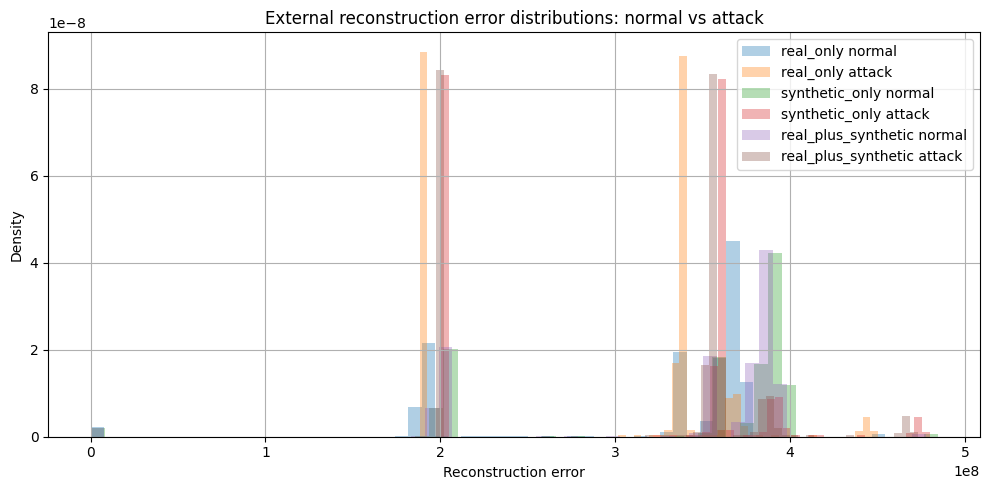

In [23]:
plt.figure(figsize=(10, 5))

for scenario in SCENARIOS:
    plt.hist(
        external_errors[scenario][y_external == 0],
        bins=60,
        alpha=0.35,
        density=True,
        label=f"{scenario} normal"
    )
    plt.hist(
        external_errors[scenario][y_external == 1],
        bins=60,
        alpha=0.35,
        density=True,
        label=f"{scenario} attack"
    )

plt.xlabel("Reconstruction error")
plt.ylabel("Density")
plt.title("External reconstruction error distributions: normal vs attack")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


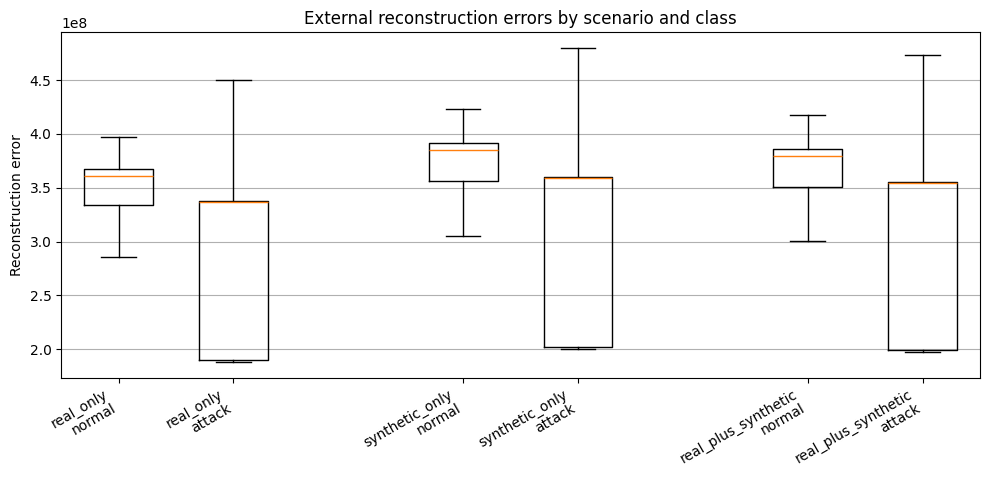

In [24]:
plt.figure(figsize=(10, 5))

for scenario in SCENARIOS:
    normal_scores = external_errors[scenario][y_external == 0]
    attack_scores = external_errors[scenario][y_external == 1]

    plt.boxplot(
        [normal_scores, attack_scores],
        positions=[SCENARIOS.index(scenario) * 3 + 1, SCENARIOS.index(scenario) * 3 + 2],
        widths=0.6,
        showfliers=False,
    )

positions = []
labels = []
for i, scenario in enumerate(SCENARIOS):
    positions.extend([i * 3 + 1, i * 3 + 2])
    labels.extend([f"{scenario}\nnormal", f"{scenario}\nattack"])

plt.xticks(positions, labels, rotation=30, ha="right")
plt.ylabel("Reconstruction error")
plt.title("External reconstruction errors by scenario and class")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


## 15. Curvas ROC y Precision-Recall

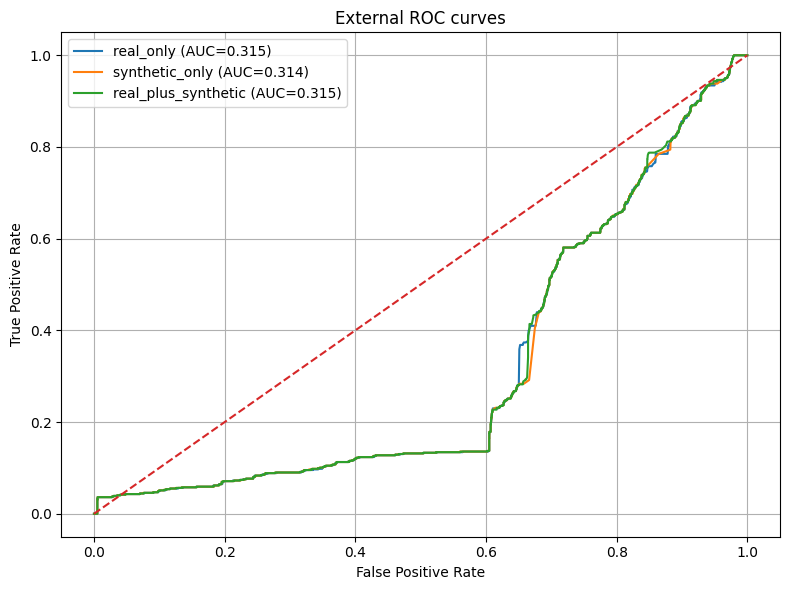

In [25]:
plt.figure(figsize=(8, 6))

for scenario in SCENARIOS:
    scores = external_errors[scenario]
    if len(np.unique(y_external)) < 2:
        continue

    fpr, tpr, _ = roc_curve(y_external, scores)
    auc_value = roc_auc_score(y_external, scores)
    plt.plot(fpr, tpr, label=f"{scenario} (AUC={auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("External ROC curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


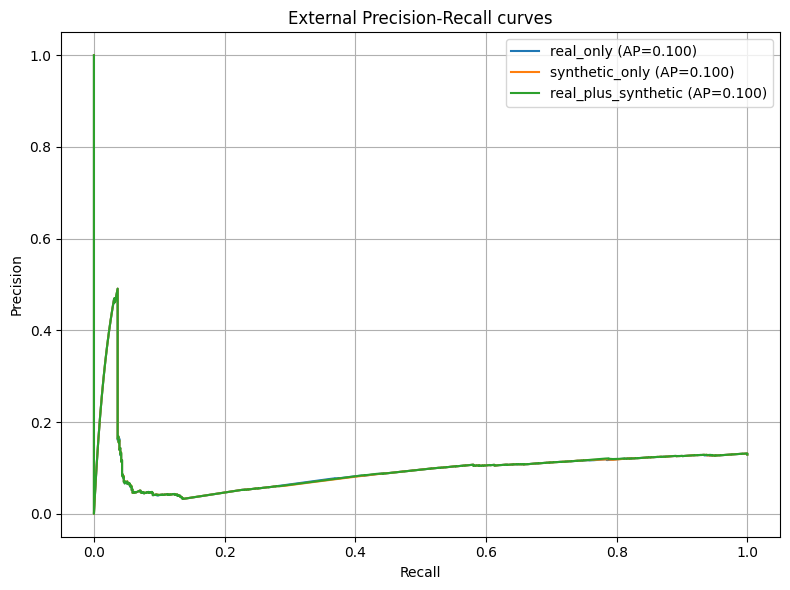

In [26]:
plt.figure(figsize=(8, 6))

for scenario in SCENARIOS:
    scores = external_errors[scenario]
    if len(np.unique(y_external)) < 2:
        continue

    precision, recall, _ = precision_recall_curve(y_external, scores)
    ap_value = average_precision_score(y_external, scores)
    plt.plot(recall, precision, label=f"{scenario} (AP={ap_value:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("External Precision-Recall curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 16. Comparación de métricas por escenario

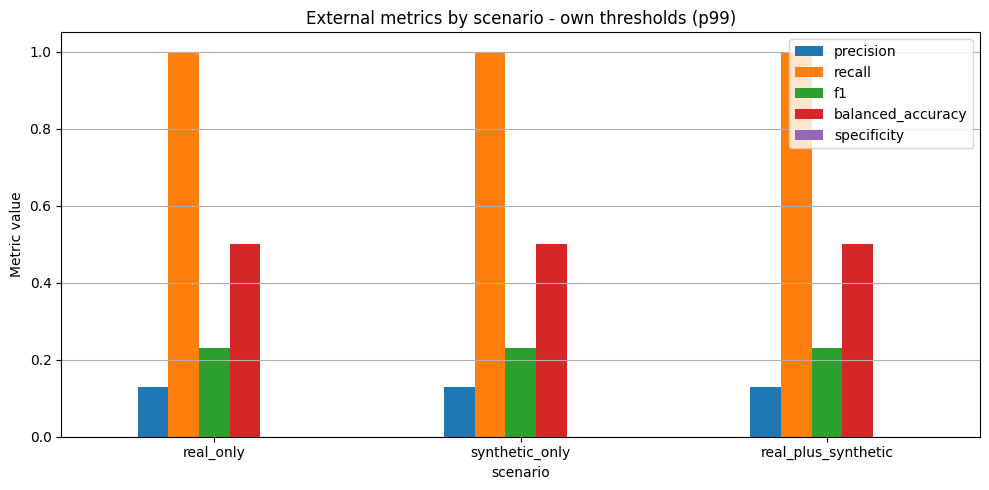

In [27]:
metrics_to_plot = ["precision", "recall", "f1", "balanced_accuracy", "specificity"]

plot_df = main_own_df.set_index("scenario")[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Metric value")
ax.set_title(f"External metrics by scenario - own thresholds ({PRIMARY_TAU_NAME})")
ax.grid(True, axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


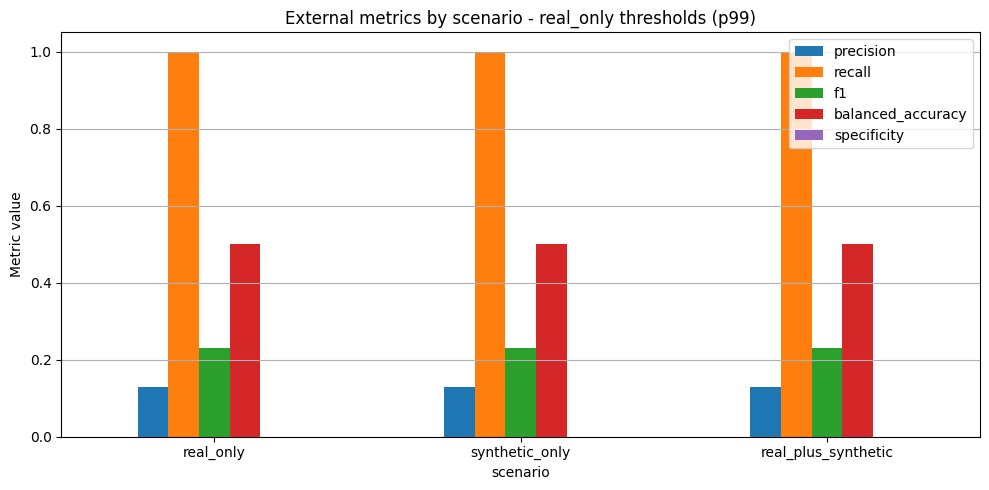

In [28]:
plot_df = main_baseline_tau_df.set_index("scenario")[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Metric value")
ax.set_title(f"External metrics by scenario - real_only thresholds ({PRIMARY_TAU_NAME})")
ax.grid(True, axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 17. Análisis por ataque

Esta sección calcula métricas por ataque usando `attack_id` a nivel de ventana.  
Sirve para identificar qué ataques se detectan mejor o peor por escenario.

Una ventana puede contener más de un `attack_id` si cruza intervalos; para simplificar, se analiza el primer ID presente.


In [29]:
window_meta = window_meta_any.copy()
window_meta["primary_attack_id"] = window_meta["window_attack_ids"].replace("", np.nan).str.split("|").str[0]
window_meta["primary_attack_name"] = window_meta["window_attack_names"].replace("", np.nan).str.split("|").str[0]

display(window_meta.head())


,window_start_time,window_end_time,window_attack_label,window_attack_ratio,window_attack_ids,window_attack_names,primary_attack_id,primary_attack_name
0,2026-03-11 09:00:00,2026-03-11 09:00:59,0,0.0,,,NaN,NaN
1,2026-03-11 09:00:05,2026-03-11 09:01:04,0,0.0,,,NaN,NaN
2,2026-03-11 09:00:10,2026-03-11 09:01:09,0,0.0,,,NaN,NaN
3,2026-03-11 09:00:15,2026-03-11 09:01:14,0,0.0,,,NaN,NaN
4,2026-03-11 09:00:20,2026-03-11 09:01:19,0,0.0,,,NaN,NaN


In [30]:
attack_level_rows = []

tau_name = PRIMARY_TAU_NAME

for scenario in SCENARIOS:
    scores = external_errors[scenario]
    tau = float(tau_dicts[scenario][tau_name])
    preds = (scores > tau).astype(int)

    eval_df = window_meta.copy()
    eval_df["score"] = scores
    eval_df["pred"] = preds
    eval_df["true"] = y_external

    attack_df = eval_df[eval_df["true"] == 1].copy()

    for attack_id, group in attack_df.groupby("primary_attack_id", dropna=False):
        if pd.isna(attack_id):
            attack_id = "unknown"

        attack_level_rows.append({
            "scenario": scenario,
            "tau_name": tau_name,
            "attack_id": attack_id,
            "n_windows": int(len(group)),
            "detected_windows": int(group["pred"].sum()),
            "attack_recall": float(group["pred"].mean()),
            "mean_score": float(group["score"].mean()),
            "p95_score": float(np.percentile(group["score"], 95)),
        })

attack_level_df = pd.DataFrame(attack_level_rows)
display(attack_level_df)


,scenario,tau_name,attack_id,n_windows,detected_windows,attack_recall,mean_score,p95_score
0,real_only,p99,1.0,72,72,1.0,367454208.0,372723392.0
1,real_only,p99,10.0,72,72,1.0,189758048.0,190426336.0
2,real_only,p99,11.0,72,72,1.0,189246176.0,189772672.0
3,real_only,p99,2.0,72,72,1.0,336357952.0,338510208.0
4,real_only,p99,3.0,72,72,1.0,337429952.0,337966464.0
5,real_only,p99,4.0,72,72,1.0,337482464.0,337498720.0
6,real_only,p99,5.0,72,72,1.0,337202912.0,338642272.0
7,real_only,p99,6.0,36,36,1.0,338069888.0,339282624.0
8,real_only,p99,7.0,60,60,1.0,382213024.0,446175872.0
9,real_only,p99,8.0,72,72,1.0,189554832.0,190281840.0


scenario,real_only,real_plus_synthetic,synthetic_only
attack_id,,,
1.0,1.0,1.0,1.0
10.0,1.0,1.0,1.0
11.0,1.0,1.0,1.0
2.0,1.0,1.0,1.0
3.0,1.0,1.0,1.0
4.0,1.0,1.0,1.0
5.0,1.0,1.0,1.0
6.0,1.0,1.0,1.0
7.0,1.0,1.0,1.0


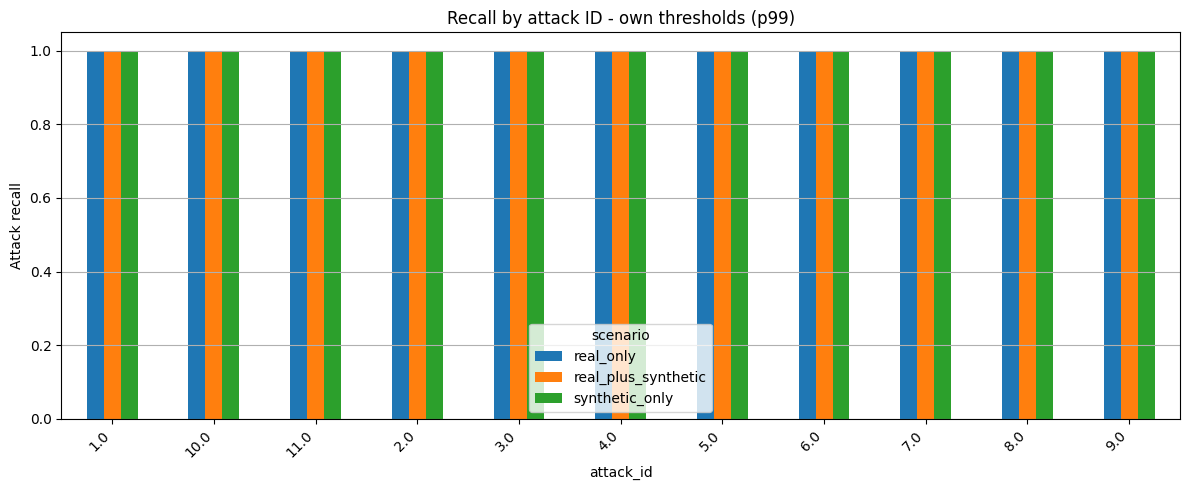

In [31]:
pivot_attack_recall = attack_level_df.pivot(
    index="attack_id",
    columns="scenario",
    values="attack_recall"
)

display(pivot_attack_recall)

ax = pivot_attack_recall.plot(kind="bar", figsize=(12, 5))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Attack recall")
ax.set_title(f"Recall by attack ID - own thresholds ({PRIMARY_TAU_NAME})")
ax.grid(True, axis="y")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 18. Sensibilidad a estrategia de etiqueta de ventana

Se repiten las métricas principales cambiando la forma de etiquetar una ventana como ataque.

Esto es útil porque una ventana puede mezclar timesteps normales y de ataque cerca de las fronteras.


In [32]:
sensitivity_rows = []

for label_strategy_name, y_strategy in labels_by_strategy.items():
    for scenario in SCENARIOS:
        scores = external_errors[scenario]

        for tau_name, tau in tau_dicts[scenario].items():
            metrics = compute_classification_metrics(y_strategy, scores, float(tau))
            row = {
                "label_strategy": label_strategy_name,
                "scenario": scenario,
                "tau_name": tau_name,
                "roc_auc": safe_auc(y_strategy, scores),
                "pr_auc": safe_pr_auc(y_strategy, scores),
            }
            row.update(metrics)
            sensitivity_rows.append(row)

sensitivity_df = pd.DataFrame(sensitivity_rows)

display(
    sensitivity_df[sensitivity_df["tau_name"] == PRIMARY_TAU_NAME][[
        "label_strategy", "scenario", "tau_name", "roc_auc", "pr_auc",
        "precision", "recall", "f1", "balanced_accuracy", "specificity", "fpr"
    ]]
)


,label_strategy,scenario,tau_name,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,specificity,fpr
3,any,real_only,p99,0.315478,0.099899,0.129189,1.0,0.228817,0.5,0.0,1.0
8,any,synthetic_only,p99,0.313794,0.099834,0.129189,1.0,0.228817,0.5,0.0,1.0
13,any,real_plus_synthetic,p99,0.315272,0.099676,0.129189,1.0,0.228817,0.5,0.0,1.0
18,ratio_10,real_only,p99,0.315579,0.096843,0.125716,1.0,0.223353,0.5,0.0,1.0
23,ratio_10,synthetic_only,p99,0.313963,0.096773,0.125716,1.0,0.223353,0.5,0.0,1.0
28,ratio_10,real_plus_synthetic,p99,0.315410,0.096637,0.125716,1.0,0.223353,0.5,0.0,1.0
33,ratio_20,real_only,p99,0.315799,0.093835,0.122243,1.0,0.217855,0.5,0.0,1.0
38,ratio_20,synthetic_only,p99,0.314249,0.093759,0.122243,1.0,0.217855,0.5,0.0,1.0
43,ratio_20,real_plus_synthetic,p99,0.315698,0.093651,0.122243,1.0,0.217855,0.5,0.0,1.0
48,ratio_50,real_only,p99,0.317535,0.082222,0.108352,1.0,0.195519,0.5,0.0,1.0


## 19. Guardado de resultados externos

In [33]:
external_metrics_df.to_csv(EXTERNAL_RESULTS_DIR / "external_metrics_own_thresholds.csv", index=False)
baseline_tau_external_df.to_csv(EXTERNAL_RESULTS_DIR / "external_metrics_real_only_thresholds.csv", index=False)
main_own_df.to_csv(EXTERNAL_RESULTS_DIR / f"main_metrics_own_thresholds_{PRIMARY_TAU_NAME}.csv", index=False)
main_baseline_tau_df.to_csv(EXTERNAL_RESULTS_DIR / f"main_metrics_real_only_thresholds_{PRIMARY_TAU_NAME}.csv", index=False)
attack_level_df.to_csv(EXTERNAL_RESULTS_DIR / f"attack_level_metrics_{PRIMARY_TAU_NAME}.csv", index=False)
sensitivity_df.to_csv(EXTERNAL_RESULTS_DIR / "label_strategy_sensitivity.csv", index=False)
label_counts_df.to_csv(EXTERNAL_RESULTS_DIR / "window_label_counts_by_strategy.csv", index=False)

window_meta_out = window_meta_any.copy()
window_meta_out["label_any"] = labels_by_strategy["any"]

for scenario in SCENARIOS:
    window_meta_out[f"score_{scenario}"] = external_errors[scenario]
    for tau_name, tau in tau_dicts[scenario].items():
        window_meta_out[f"pred_{scenario}_{tau_name}"] = (external_errors[scenario] > float(tau)).astype(int)

window_meta_out.to_csv(EXTERNAL_RESULTS_DIR / "external_window_scores_predictions.csv", index=False)

for scenario in SCENARIOS:
    np.save(EXTERNAL_RESULTS_DIR / f"external_errors_{scenario}.npy", external_errors[scenario])

external_config = {
    "validation_type": "external_supervised",
    "a12_labeled_path": str(A12_LABELED_PATH),
    "models_dir": str(MODELS_DIR),
    "internal_artifacts_dir": str(INTERNAL_ARTIFACTS_DIR),
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "primary_label_strategy": primary_label_strategy,
    "primary_tau_name": PRIMARY_TAU_NAME,
    "scenarios": SCENARIOS,
    "n_windows": int(len(y_external)),
    "n_attack_windows_any": int(y_external.sum()),
    "n_normal_windows_any": int((y_external == 0).sum()),
}

with open(EXTERNAL_RESULTS_DIR / "config.json", "w") as f:
    json.dump(external_config, f, indent=4)

print("External validation results saved to:", EXTERNAL_RESULTS_DIR.resolve())


External validation results saved to: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\artifacts\tstr_external_validation


## 20. Guía de interpretación

Para esta evaluación, el resultado más importante no es solo ROC-AUC, sino el balance entre:

- `recall`: cuántas ventanas de ataque detecta;
- `precision`: cuántas alarmas corresponden realmente a ataques;
- `F1`: balance entre precision y recall;
- `specificity` / `FPR`: control de falsas alarmas;
- análisis por ataque: cuáles ataques se detectan o se pierden.

### Lectura esperada

Si `real_plus_synthetic` mejora sobre `real_only`, lo ideal sería observar:

- mayor recall,
- F1 igual o superior,
- FPR no excesivamente mayor,
- detección de más ataques individuales.

Si `real_plus_synthetic` aumenta recall pero baja precision, se puede reportar como un trade-off entre sensibilidad y falsas alarmas.

Si `synthetic_only` funciona peor que `real_only`, no necesariamente invalida el generador. Lo importante para la tesis es si los sintéticos aportan cuando se usan como augmentación junto con datos reales.
